In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
df = pd.read_csv('..\\data\\mega_FA_bathy.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,FA,ps_z,stein_z,bathy
0,49.62,-129.98,0.816961,366.0,523.431597,564.247252,2.029732,2816.350677,2929.908563,-2408
1,44.68,-125.29,9.119624,79.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2114
2,44.66,-125.27,9.119624,81.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
3,44.66,-125.27,9.119624,93.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
4,44.66,-125.26,9.119624,77.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2280


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [3]:
x = df.drop(columns=['q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [4]:
x.head()

,lat,long,age,q_ihfc,bathy
0,49.62,-129.98,0.816961,366.0,-2408
1,44.68,-125.29,9.119624,79.0,-2114
2,44.66,-125.27,9.119624,81.0,-2269
3,44.66,-125.27,9.119624,93.0,-2269
4,44.66,-125.26,9.119624,77.0,-2280


In [5]:
x.shape

(7445, 5)

In [6]:
y.head()

0     2.029732
1   -66.546684
2   -66.546684
3   -66.546684
4   -66.546684
Name: FA, dtype: float64

In [7]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [8]:
x_train.shape

(5956, 5)

this is the raw validation data

In [9]:
x_test.shape

(1489, 5)

In [10]:
x_train.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,5956.000,5956.000,5956.000,5956.000,5956.000
mean,46.212,-125.759,6.203,621.851,-1254.558
std,3.536,3.552,5.978,1722.257,1680.101
min,37.030,-132.420,0.021,-182.200,-4764.000
25%,44.628,-128.680,0.817,87.000,-2584.250
50%,47.850,-127.680,3.495,189.600,-2420.000
75%,48.450,-122.530,9.542,415.000,554.000
max,54.940,-119.000,35.200,26000.000,2860.000


In [11]:
x_test.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,1489.000,1489.000,1489.000,1489.000,1489.000
mean,46.032,-125.641,6.387,556.886,-1184.275
std,3.596,3.583,6.061,1391.972,1700.556
min,37.050,-132.310,0.010,-53.000,-4575.000
25%,43.960,-128.680,0.804,84.000,-2585.000
50%,47.850,-127.520,4.266,188.000,-2395.000
75%,48.440,-122.410,9.556,408.110,642.000
max,54.910,-119.010,31.536,17550.000,1956.000


In [12]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

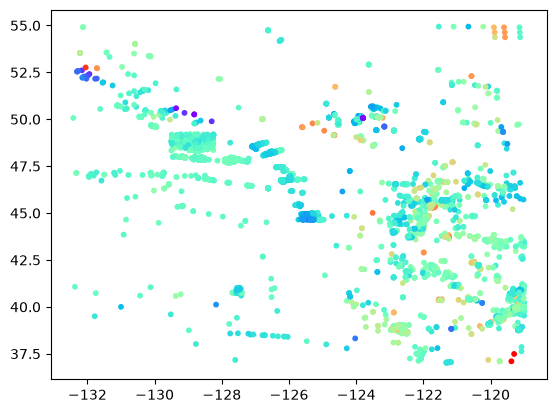

In [13]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

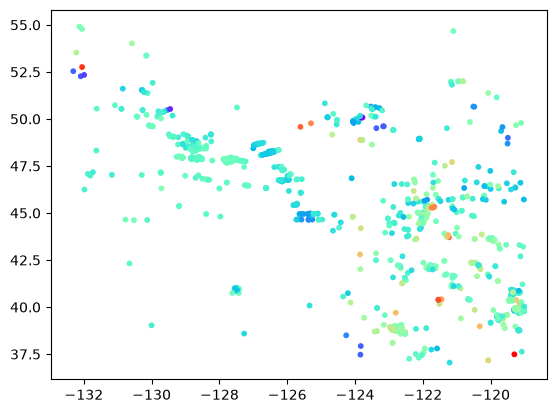

In [14]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [15]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [16]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1240
[LightGBM] [Info] Number of data points in the train set: 5956, number of used features: 5
[LightGBM] [Info] Start training from score -7.123717


In [17]:
y_pred = model.predict(x_test)

In [18]:
y_pred.shape

(1489,)

In [19]:
y_pred, y_pred.shape

(array([-44.94192401,  38.83469692,  48.01827074, ...,  26.34445725,
        -19.40823669,  -8.98998951], shape=(1489,)),
 (1489,))

In [20]:
residuals = y_test - y_pred

negative mean: overpredicting

In [21]:
residuals.head(), residuals.describe()

(5450   -10.080350
 2007    -1.190017
 6763    21.184602
 7198    -0.398581
 6867     7.958075
 Name: FA, dtype: float64,
 count    1489.000000
 mean       -0.209941
 std        11.715836
 min       -93.621934
 25%        -1.959222
 50%        -0.272565
 75%         2.167188
 max        73.054867
 Name: FA, dtype: float64)

In [22]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [23]:
pd.DataFrame(dfr).to_csv('..\\created_data\\Cbth_grav_residuals.csv', index=False)

with open('..\\created_data\\Cbth_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'and this was for lat, long, age, ihfc, and bathy')

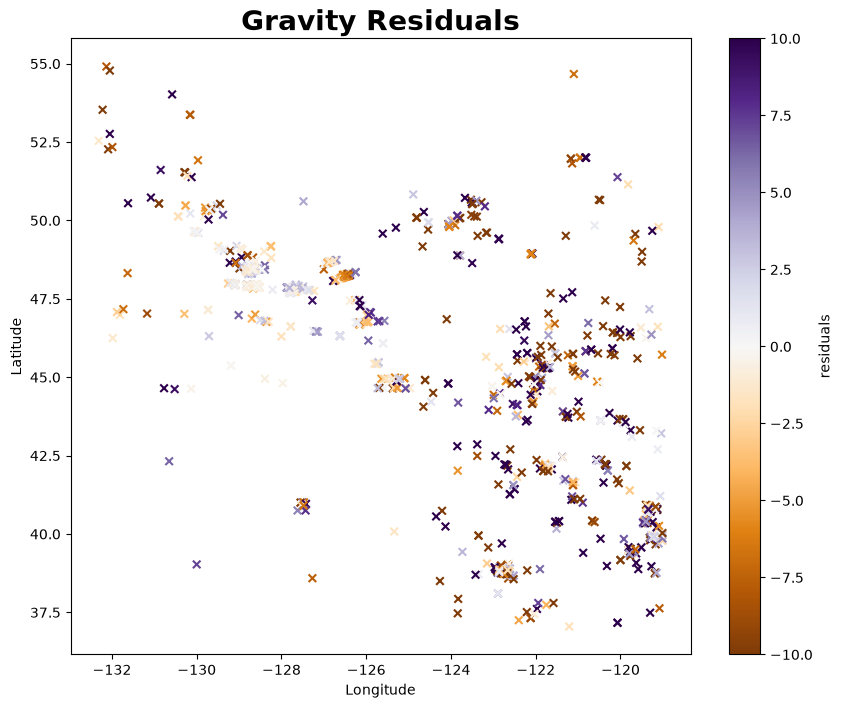

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\Cbth_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

In [25]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [26]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [27]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [28]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [29]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 249, 249, 249], shape=(60042,)),
 array([190, 191, 192, ..., 239, 240, 241], shape=(60042,)))

In [30]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[75.37336551, 73.48235034, 71.59133517, 69.70032   , 67.80930483],
        [76.01873087, 74.1277157 , 72.23670053, 70.34568536, 68.45467019],
        [76.66409623, 74.77308106, 72.88206589, 70.99105072, 69.10003555],
        [77.30946158, 75.41844641, 73.52743124, 71.63641607, 69.77689245],
        [77.95482694, 76.06381177, 74.23941224, 72.46031208, 70.68121191]]),
 array([[8.52777562, 8.58792585, 8.64807608, 8.70822631, 8.76837654],
        [8.54843399, 8.60858422, 8.66873445, 8.72888468, 8.78903491],
        [8.56909236, 8.62924259, 8.68939282, 8.74954305, 8.80969328],
        [8.58975073, 8.64990096, 8.71005119, 8.77020142, 8.82724593],
        [8.6104091 , 8.67055933, 8.72413987, 8.77325295, 8.82236602]]),
 array([[-1773.29952042, -1676.60694898, -1579.91437755, -1483.22180611,
         -1386.52923468],
        [-1746.87195643, -1650.17938499, -1553.48681355, -1456.79424212,
         -1360.10167068],
        [-1720.44439243, -1623.75182099, -1527.05924956, -1430.36667812,


In [31]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((250, 250), (250, 250), (250, 250))

np.vstack stacks arrays as new rows

In [32]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [33]:
lola.shape

(62500, 5)

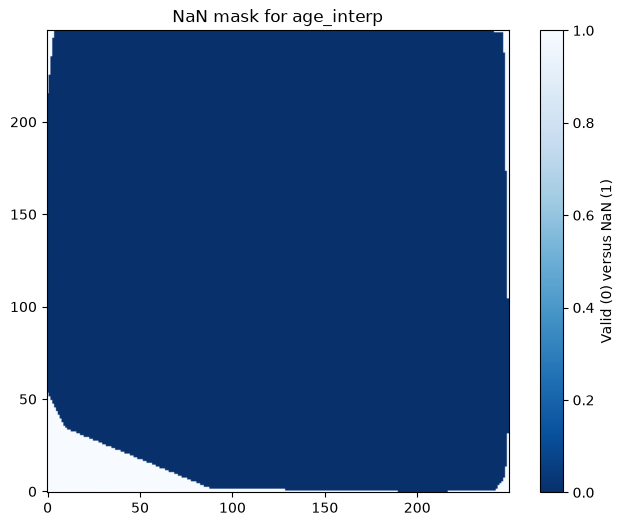

In [34]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [35]:
lola_pred = model.predict(lola)

In [36]:
lola_pred[180:184]

array([19.80324334, 19.80324334, 19.80324334, 19.80324334])

In [37]:
lola_pred = lola_pred.reshape(long.shape)

In [38]:
lola_pred.shape

(250, 250)

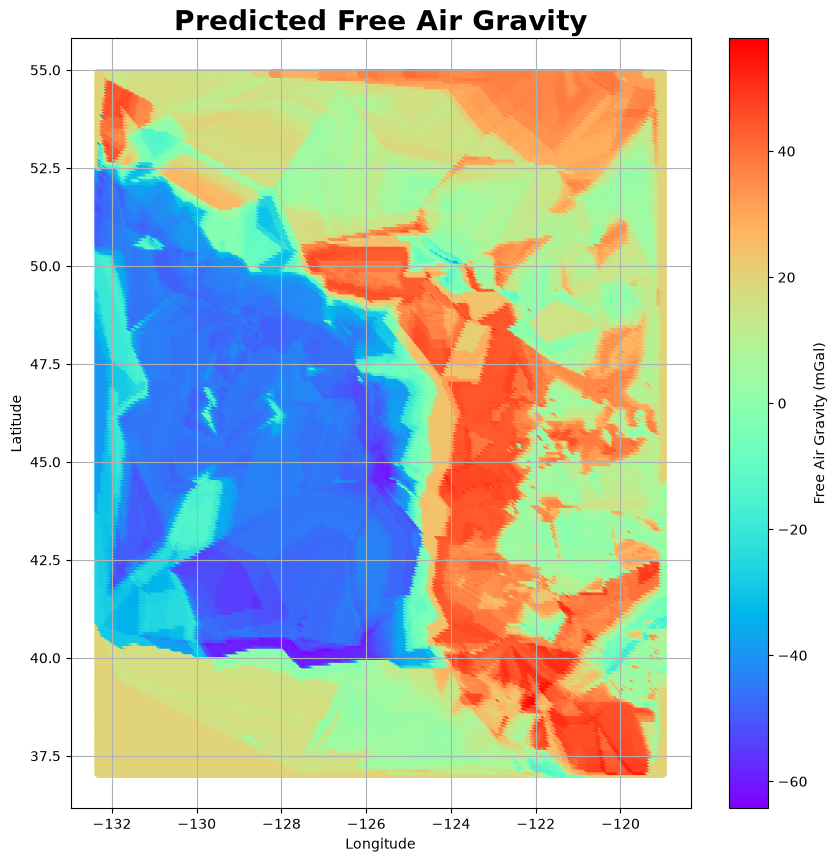

In [39]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\Cbth_grav_pred_{sp}.png', dpi=400)
plt.show()

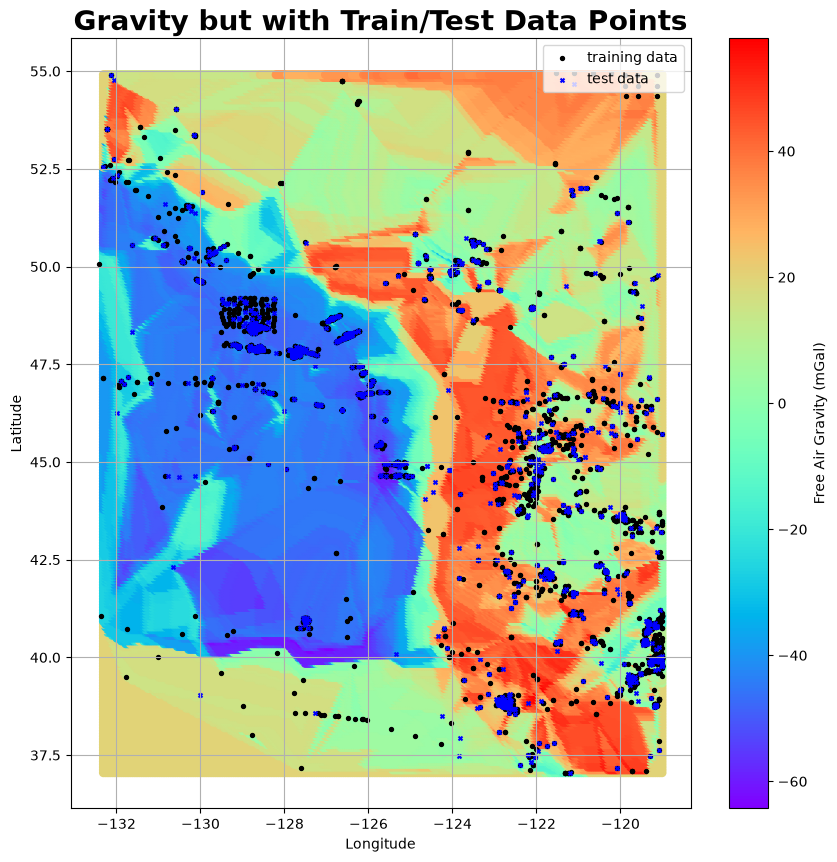

In [40]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=8, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=8, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\Cbth_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()